In [1]:
# Set up env
import os
import torch
import sklearn.model_selection
from torch import nn
import numpy as np

In [2]:
from mlxtend.data import mnist_data
X, y = mnist_data()

#create test and training data:
Xtrain,Xtest,ytrain,ytest=sklearn.model_selection.train_test_split(X,y,test_size=0.3,shuffle=True)

#transform into pytorch datasets:
trainDataset=torch.utils.data.TensorDataset(torch.tensor(Xtrain).float(),torch.tensor(ytrain).long())
testDataset=torch.utils.data.TensorDataset(torch.tensor(Xtest).float(),torch.tensor(ytest).long())

print("Xtrain:", trainDataset.tensors[0].shape)
print("ytrain:", trainDataset.tensors[1].shape)

print("Xtest:", testDataset.tensors[0].shape)
print("ytest:", testDataset.tensors[1].shape)

Xtrain: torch.Size([3500, 784])
ytrain: torch.Size([3500])
Xtest: torch.Size([1500, 784])
ytest: torch.Size([1500])


In [24]:
#make network

#we copy https://stats.stackexchange.com/questions/376312/mnist-digit-recognition-what-is-the-best-we-can-get-with-a-fully-connected-nn-o


class logRegression(nn.Module):
    def __init__(self):
        super(logRegression, self).__init__()
        self.inputLayer1=nn.Linear(784, 200, bias=True)
        self.inputLayer2=nn.Linear(200, 80, bias=True)
        self.inputLayer3=nn.Linear(80, 10, bias=True)


    def forward(self,x):
      x=nn.functional.relu(self.inputLayer1(x))
      x=nn.functional.relu(self.inputLayer2(x))
      x=self.inputLayer3(x)
      return x

testData=torch.rand((20,784))

testNet=logRegression()


output = testNet.forward(testData)
print(output)

print(output.sum(dim=1))

tensor([[ 0.0256, -0.0427,  0.0699,  0.0194,  0.0802, -0.0762, -0.1220,  0.1277,
          0.0602, -0.0352],
        [ 0.0316, -0.0612,  0.0738, -0.0436,  0.0871, -0.0135, -0.0684,  0.0837,
          0.1002, -0.0837],
        [ 0.0110, -0.0602,  0.0432,  0.0276,  0.0462, -0.0351, -0.1164,  0.0871,
          0.0746, -0.0554],
        [ 0.0586, -0.0277,  0.0755, -0.0229,  0.0733, -0.0573, -0.1121,  0.0579,
          0.0538, -0.0566],
        [ 0.0391, -0.0436,  0.0529,  0.0056,  0.1127, -0.0421, -0.1080,  0.0929,
          0.0197, -0.0623],
        [ 0.0285, -0.0218,  0.0680,  0.0467,  0.0851, -0.0254, -0.1233,  0.0552,
          0.0775, -0.0880],
        [ 0.0054, -0.0440,  0.0562,  0.0050,  0.0993, -0.0422, -0.1018,  0.0823,
          0.0591, -0.0776],
        [ 0.0228, -0.0610,  0.0403, -0.0080,  0.0547, -0.0598, -0.0997,  0.1372,
          0.0585, -0.0395],
        [ 0.0476, -0.0551,  0.0568,  0.0423,  0.1216, -0.0807, -0.1068,  0.0346,
          0.0804, -0.0555],
        [ 0.0329, -

In [4]:
testnet=nn.Sequential(
        nn.Linear(784, 200, bias=True),
        nn.ReLU(),
        nn.Linear(200, 80, bias=True),
        nn.ReLU(),
        nn.Linear(80, 10, bias=True),
        nn.Softmax())

testnet.forward(testData)


/usr/local/lib/python3.13/dist-packages/torch/nn/modules/module.py:1779: UserWarning: Implicit dimension choice for softmax has been deprecated. Change the call to include dim=X as an argument.
  return self._call_impl(*args, **kwargs)


tensor([[0.1062, 0.1096, 0.1074, 0.0848, 0.1051, 0.1055, 0.0959, 0.0946, 0.1046,
         0.0864],
        [0.0959, 0.1161, 0.1049, 0.0860, 0.1048, 0.0992, 0.0998, 0.0944, 0.1085,
         0.0904],
        [0.0990, 0.1138, 0.1044, 0.0849, 0.0998, 0.1039, 0.1010, 0.0949, 0.1101,
         0.0881],
        [0.1053, 0.1165, 0.1047, 0.0876, 0.1068, 0.1009, 0.0971, 0.0917, 0.1080,
         0.0814],
        [0.0982, 0.1118, 0.1047, 0.0881, 0.1024, 0.0981, 0.0987, 0.0948, 0.1117,
         0.0915],
        [0.0990, 0.1175, 0.1085, 0.0892, 0.1008, 0.1031, 0.0963, 0.0937, 0.1067,
         0.0850],
        [0.1000, 0.1167, 0.1055, 0.0892, 0.1014, 0.0993, 0.1009, 0.0928, 0.1071,
         0.0870],
        [0.1011, 0.1139, 0.1055, 0.0899, 0.1011, 0.1027, 0.0956, 0.0958, 0.1055,
         0.0888],
        [0.1014, 0.1137, 0.1086, 0.0856, 0.1001, 0.1064, 0.0977, 0.0931, 0.1033,
         0.0902],
        [0.1016, 0.1137, 0.1046, 0.0901, 0.1003, 0.1043, 0.0952, 0.0911, 0.1085,
         0.0905],
        [0

In [5]:
output = testnet(testData)

print(output.sum(dim=1))

tensor([1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000], grad_fn=<SumBackward1>)


In [6]:
#setup training and run
nEpoch=200
learningRate=0.001
batchSize=64

trainDataLoader=torch.utils.data.DataLoader(trainDataset,batch_size=batchSize,shuffle=True)

model=logRegression()

#optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)
optimizer=torch.optim.Adam(model.parameters(),learningRate,weight_decay=0.01)

#we use the binary cross entropy loss (like we did in the numpy version)
loss_fn=nn.functional.cross_entropy

accuracy=np.zeros(nEpoch)

for iEpoch in range(nEpoch):
  estimatedLabels=np.empty((0,))
  trueLabels=np.empty((0,))
  for xbatch,ybatch in trainDataLoader:
    y_pred=model(xbatch)

    # calculate the loss
    loss = loss_fn(y_pred,ybatch)

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Populate the grad parameters - aka how much would loss change if weights changed
    loss.backward()

    # Update the weights
    optimizer.step()


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

  # print the accuracy
  accuracy[iEpoch]=np.mean(np.equal(estimatedLabels,trueLabels))
  print(iEpoch,accuracy[iEpoch])

accuracy

0 0.7308571428571429
1 0.9277142857142857
2 0.9631428571428572
3 0.9774285714285714
4 0.9851428571428571
5 0.9914285714285714
6 0.9868571428571429
7 0.9677142857142857
8 0.9748571428571429
9 0.9808571428571429
10 0.9945714285714286
11 0.9997142857142857
12 1.0
13 1.0
14 1.0
15 1.0
16 1.0
17 1.0
18 1.0
19 1.0
20 1.0
21 1.0
22 1.0
23 1.0
24 1.0
25 1.0
26 1.0
27 1.0
28 1.0
29 0.9437142857142857
30 0.9108571428571428
31 0.9528571428571428
32 0.9597142857142857
33 0.9848571428571429
34 0.988
35 0.9948571428571429
36 0.9977142857142857
37 0.9997142857142857
38 1.0
39 1.0
40 1.0
41 1.0
42 1.0
43 1.0
44 1.0
45 1.0
46 1.0
47 1.0
48 1.0
49 1.0
50 1.0
51 1.0
52 1.0
53 1.0
54 0.9994285714285714
55 0.9525714285714286
56 0.93
57 0.976
58 0.9851428571428571
59 0.9874285714285714
60 0.9928571428571429
61 0.9982857142857143
62 0.9914285714285714
63 0.994
64 0.9934285714285714
65 0.9962857142857143
66 0.9988571428571429
67 0.9982857142857143
68 0.994
69 0.9962857142857143
70 0.9971428571428571
71 0.9865

array([0.73085714, 0.92771429, 0.96314286, 0.97742857, 0.98514286,
       0.99142857, 0.98685714, 0.96771429, 0.97485714, 0.98085714,
       0.99457143, 0.99971429, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.94371429,
       0.91085714, 0.95285714, 0.95971429, 0.98485714, 0.988     ,
       0.99485714, 0.99771429, 0.99971429, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.99942857,
       0.95257143, 0.93      , 0.976     , 0.98514286, 0.98742857,
       0.99285714, 0.99828571, 0.99142857, 0.994     , 0.99342857,
       0.99628571, 0.99885714, 0.99828571, 0.994     , 0.99628571,
       0.99714286, 0.98657143, 0.97942857, 0.96285714, 0.98114

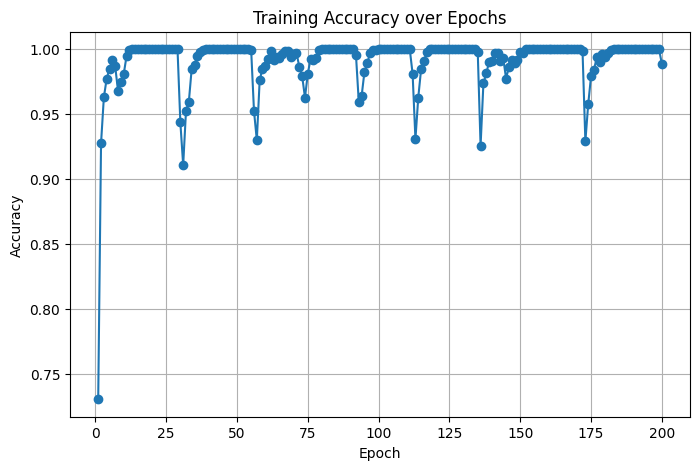

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, nEpoch + 1),
    accuracy,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Epochs")
plt.grid(True)

plt.show()

In [8]:
accuracy

array([0.73085714, 0.92771429, 0.96314286, 0.97742857, 0.98514286,
       0.99142857, 0.98685714, 0.96771429, 0.97485714, 0.98085714,
       0.99457143, 0.99971429, 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.94371429,
       0.91085714, 0.95285714, 0.95971429, 0.98485714, 0.988     ,
       0.99485714, 0.99771429, 0.99971429, 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 0.99942857,
       0.95257143, 0.93      , 0.976     , 0.98514286, 0.98742857,
       0.99285714, 0.99828571, 0.99142857, 0.994     , 0.99342857,
       0.99628571, 0.99885714, 0.99828571, 0.994     , 0.99628571,
       0.99714286, 0.98657143, 0.97942857, 0.96285714, 0.98114

In [11]:
np.equal(estimatedLabels,trueLabels)
a,yhat=torch.max(y_pred,1)
yhat

tensor([9, 9, 2, 4, 7, 7, 7, 8, 2, 8, 1, 3, 3, 6, 8, 5, 8, 9, 8, 2, 6, 1, 7, 2,
        3, 5, 1, 8, 1, 9, 9, 1, 7, 5, 1, 0, 2, 7, 8, 4, 8, 1, 3, 6, 6, 0, 6, 1,
        3, 8, 0, 7, 5, 1, 6, 5, 9, 9, 5, 0, 9, 7, 8, 5])

In [12]:
#test performance:
testDataLoader=torch.utils.data.DataLoader(testDataset,batch_size=batchSize,shuffle=True)

estimatedLabels=np.empty((0,))
trueLabels=np.empty((0,))
for xbatch,ybatch in testDataLoader:
    y_pred=model(xbatch)


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

testAcc=np.mean(np.equal(estimatedLabels,trueLabels))
print(testAcc)

0.936


The weird dips are suspected to be caused by ADAM - lets switch to SGD to confirm if this is the case

In [13]:
#setup training and run
nEpoch=200
learningRate=0.001
batchSize=64

trainDataLoader=torch.utils.data.DataLoader(trainDataset,batch_size=batchSize,shuffle=True)

model=logRegression()

optimizer = torch.optim.SGD(model.parameters(), lr=learningRate)
#optimizer=torch.optim.Adam(model.parameters(),learningRate,weight_decay=0.01)

#we use the binary cross entropy loss (like we did in the numpy version)
loss_fn=nn.functional.cross_entropy

accuracy=np.zeros(nEpoch)

for iEpoch in range(nEpoch):
  estimatedLabels=np.empty((0,))
  trueLabels=np.empty((0,))
  for xbatch,ybatch in trainDataLoader:
    y_pred=model(xbatch)

    # calculate the loss
    loss = loss_fn(y_pred,ybatch)

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Populate the grad parameters - aka how much would loss change if weights changed
    loss.backward()

    # Update the weights
    optimizer.step()


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

  # print the accuracy
  accuracy[iEpoch]=np.mean(np.equal(estimatedLabels,trueLabels))
  print(iEpoch,accuracy[iEpoch])

accuracy

0 0.6437142857142857
1 0.8585714285714285
2 0.912
3 0.9371428571428572
4 0.954
5 0.9682857142857143
6 0.9805714285714285
7 0.9868571428571429
8 0.9902857142857143
9 0.9928571428571429
10 0.9945714285714286
11 0.9962857142857143
12 0.9965714285714286
13 0.9977142857142857
14 0.998
15 0.9988571428571429
16 0.9994285714285714
17 0.9994285714285714
18 1.0
19 0.9997142857142857
20 1.0
21 1.0
22 1.0
23 1.0
24 1.0
25 1.0
26 1.0
27 1.0
28 1.0
29 1.0
30 1.0
31 1.0
32 1.0
33 1.0
34 1.0
35 1.0
36 1.0
37 1.0
38 1.0
39 1.0
40 1.0
41 1.0
42 1.0
43 1.0
44 1.0
45 1.0
46 1.0
47 1.0
48 1.0
49 1.0
50 1.0
51 1.0
52 1.0
53 1.0
54 1.0
55 1.0
56 1.0
57 1.0
58 1.0
59 1.0
60 1.0
61 1.0
62 1.0
63 1.0
64 1.0
65 1.0
66 1.0
67 1.0
68 1.0
69 1.0
70 1.0
71 1.0
72 1.0
73 1.0
74 1.0
75 1.0
76 1.0
77 1.0
78 1.0
79 1.0
80 1.0
81 1.0
82 1.0
83 1.0
84 1.0
85 1.0
86 1.0
87 1.0
88 1.0
89 1.0
90 1.0
91 1.0
92 1.0
93 1.0
94 1.0
95 1.0
96 1.0
97 1.0
98 1.0
99 1.0
100 1.0
101 1.0
102 1.0
103 1.0
104 1.0
105 1.0
106 1.0
107 1.0


array([0.64371429, 0.85857143, 0.912     , 0.93714286, 0.954     ,
       0.96828571, 0.98057143, 0.98685714, 0.99028571, 0.99285714,
       0.99457143, 0.99628571, 0.99657143, 0.99771429, 0.998     ,
       0.99885714, 0.99942857, 0.99942857, 1.        , 0.99971429,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

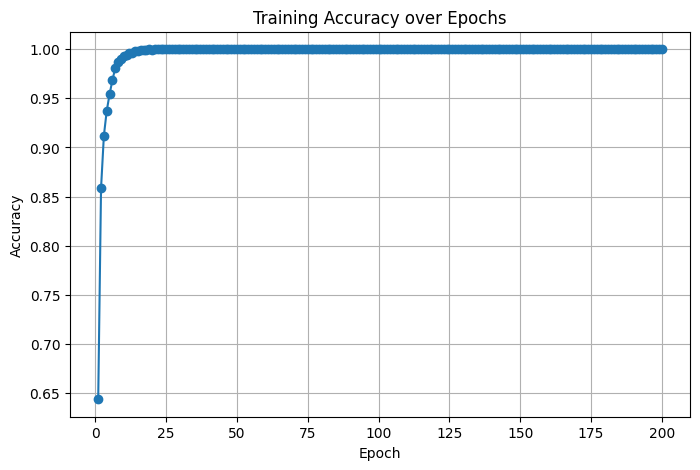

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, nEpoch + 1),
    accuracy,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Epochs")
plt.grid(True)

plt.show()

In [15]:
#test performance:
testDataLoader=torch.utils.data.DataLoader(testDataset,batch_size=batchSize,shuffle=True)

estimatedLabels=np.empty((0,))
trueLabels=np.empty((0,))
for xbatch,ybatch in testDataLoader:
    y_pred=model(xbatch)


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

testAcc=np.mean(np.equal(estimatedLabels,trueLabels))
print(testAcc)

0.9113333333333333


Now the dips are gone but performance is not as good - lets try with ADAMW which decouples the weightdecay from the gradients. This should make the optimizer more stable.

In [16]:
#setup training and run
nEpoch=200
learningRate=0.001
batchSize=64

trainDataLoader=torch.utils.data.DataLoader(trainDataset,batch_size=batchSize,shuffle=True)

model=logRegression()

# We use ADAM as our optimizer
optimizer = torch.optim.AdamW(model.parameters(), lr=learningRate, weight_decay=0.01)

#we use cross entropy loss
loss_fn=nn.functional.cross_entropy

accuracy=np.zeros(nEpoch)

for iEpoch in range(nEpoch):
  estimatedLabels=np.empty((0,))
  trueLabels=np.empty((0,))
  for xbatch,ybatch in trainDataLoader:
    y_pred=model(xbatch)

    # calculate the loss
    loss = loss_fn(y_pred,ybatch)

    # Zero the gradients before running the backward pass.
    model.zero_grad()

    # Populate the grad parameters - aka how much would loss change if weights changed
    loss.backward()

    # Update the weights
    optimizer.step()


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

  # print the accuracy
  accuracy[iEpoch]=np.mean(np.equal(estimatedLabels,trueLabels))
  print(iEpoch,accuracy[iEpoch])

accuracy

0 0.7151428571428572
1 0.9168571428571428
2 0.9542857142857143
3 0.9811428571428571
4 0.984
5 0.9894285714285714
6 0.994
7 0.9842857142857143
8 0.9831428571428571
9 0.9914285714285714
10 0.9951428571428571
11 0.998
12 0.9917142857142857
13 0.9911428571428571
14 0.9854285714285714
15 0.9822857142857143
16 0.9765714285714285
17 0.9654285714285714
18 0.9748571428571429
19 0.9745714285714285
20 0.9871428571428571
21 0.9928571428571429
22 0.9951428571428571
23 0.9988571428571429
24 1.0
25 1.0
26 1.0
27 1.0
28 1.0
29 1.0
30 1.0
31 1.0
32 1.0
33 1.0
34 1.0
35 1.0
36 1.0
37 1.0
38 1.0
39 1.0
40 1.0
41 1.0
42 1.0
43 1.0
44 1.0
45 1.0
46 1.0
47 1.0
48 1.0
49 1.0
50 1.0
51 1.0
52 1.0
53 1.0
54 1.0
55 1.0
56 1.0
57 1.0
58 1.0
59 1.0
60 1.0
61 1.0
62 1.0
63 1.0
64 1.0
65 1.0
66 1.0
67 1.0
68 1.0
69 1.0
70 1.0
71 1.0
72 1.0
73 1.0
74 1.0
75 1.0
76 1.0
77 1.0
78 1.0
79 1.0
80 1.0
81 1.0
82 1.0
83 1.0
84 1.0
85 1.0
86 1.0
87 1.0
88 1.0
89 1.0
90 1.0
91 1.0
92 1.0
93 1.0
94 1.0
95 1.0
96 1.0
97 1.0
98 

array([0.71514286, 0.91685714, 0.95428571, 0.98114286, 0.984     ,
       0.98942857, 0.994     , 0.98428571, 0.98314286, 0.99142857,
       0.99514286, 0.998     , 0.99171429, 0.99114286, 0.98542857,
       0.98228571, 0.97657143, 0.96542857, 0.97485714, 0.97457143,
       0.98714286, 0.99285714, 0.99514286, 0.99885714, 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.        ,
       1.        , 1.        , 1.        , 1.        , 1.     

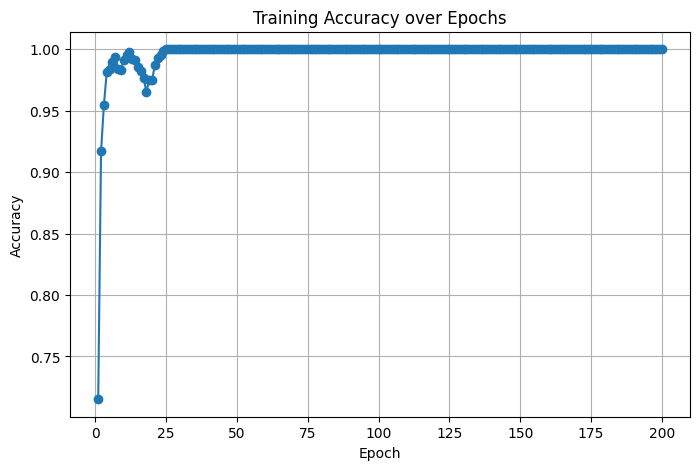

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, nEpoch + 1),
    accuracy,
    marker="o"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training Accuracy over Epochs")
plt.grid(True)

plt.show()

In [18]:
#test performance:
testDataLoader=torch.utils.data.DataLoader(testDataset,batch_size=batchSize,shuffle=True)

estimatedLabels=np.empty((0,))
trueLabels=np.empty((0,))
for xbatch,ybatch in testDataLoader:
    y_pred=model(xbatch)


    #calculate accuracy for whole training set:
    a,yhat=torch.max(y_pred,1)
    estimatedLabels=np.append(estimatedLabels,yhat)
    trueLabels=np.append(trueLabels,ybatch)

testAcc=np.mean(np.equal(estimatedLabels,trueLabels))
print(testAcc)

0.9473333333333334


Lets inspect the samples the model is getting wrong. To do this, we rerun the test but keep track of which predictions are wrong and keep the image.

In [19]:
#test performance:
testDataLoader = torch.utils.data.DataLoader(testDataset, batch_size=batchSize, shuffle=True)

estimatedLabels = np.empty((0,))
trueLabels = np.empty((0,))
allImages = np.empty((0, Xtest.shape[1]))  # keep the images too

model.eval()
with torch.no_grad():
    for xbatch, ybatch in testDataLoader:
        y_pred = model(xbatch)

        _, yhat = torch.max(y_pred, 1)

        estimatedLabels = np.append(estimatedLabels, yhat.numpy())
        trueLabels = np.append(trueLabels, ybatch.numpy())
        allImages = np.append(allImages, xbatch.numpy(), axis=0)

testAcc = np.mean(np.equal(estimatedLabels, trueLabels))
print(testAcc)

0.9473333333333334


79 wrong out of 1500


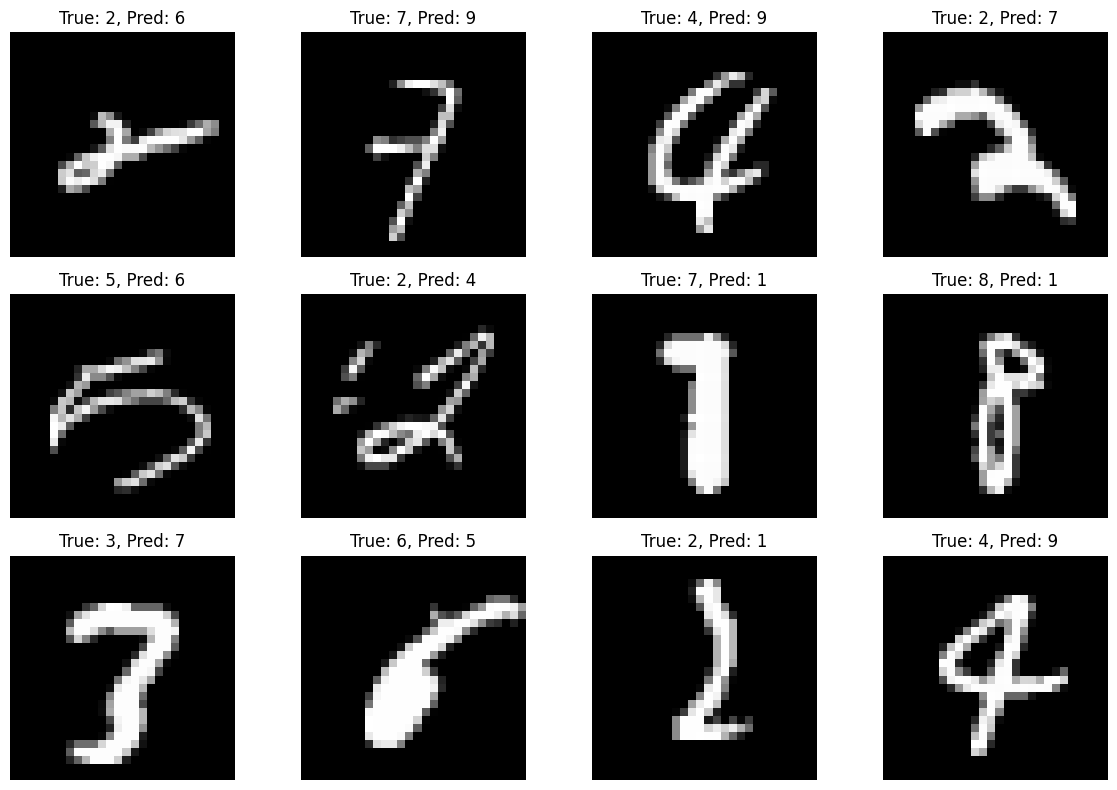

In [20]:
# find indices where prediction != true label
wrongIdx = np.where(estimatedLabels != trueLabels)[0]
print(f"{len(wrongIdx)} wrong out of {len(trueLabels)}")

# plot a handful of them
nShow = 12
plt.figure(figsize=(12, 8))
for i, idx in enumerate(wrongIdx[:nShow]):
    plt.subplot(3, 4, i + 1)
    img = allImages[idx].reshape(28, 28)
    plt.imshow(img, cmap='gray')
    plt.title(f"True: {int(trueLabels[idx])}, Pred: {int(estimatedLabels[idx])}")
    plt.axis('off')

plt.tight_layout()
plt.show()